## Importing the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, SGDRegressor

from sklearn.preprocessing import PolynomialFeatures, StandardScaler

from sklearn.metrics import r2_score

from sklearn.pipeline import Pipeline

## Creating a synthetic non linear Dataset

In [2]:
x = 6* np.random.rand(200,1)-3
y = 0.7 * x**2 + 0.3 * x + 2 + np.random.rand(200,1)

## Visualising the data

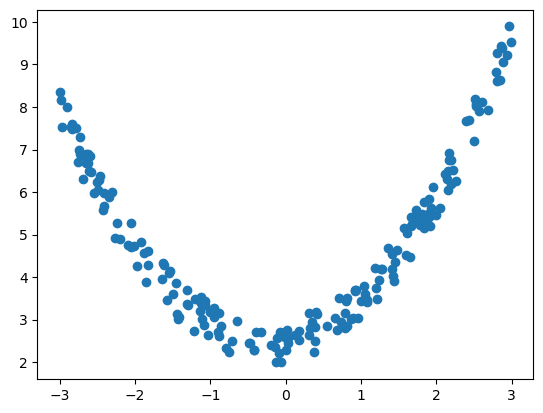

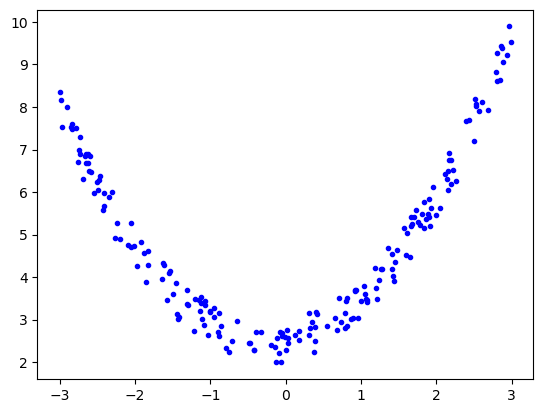

In [3]:
plt.scatter(x,y)
plt.show()
plt.plot(x,y,'.b')  # plot is used to drow line-plot however, '.b' tells it to create dots of the (x,y) with blue color, you can use '.r' for red dots
plt.show()

## Creating the Input and Output Dataframe

In [4]:
pd.DataFrame({'x':x.flatten(),  # For each x value the corresponding y value is shown in the dataframe.
             'y':y.flatten()})

,x,y
0,2.497174,7.209408
1,-1.419712,3.060981
2,0.008138,2.295843
3,1.475104,4.629752
4,-2.232885,5.269626
...,...,...
195,1.421781,4.036429
196,1.737031,5.583360
197,-2.644451,6.895961
198,2.991337,9.524423


## Spliting the data into Training and test set

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [7]:
lr = LinearRegression()
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Predicted Values Vs Actual Values

In [38]:
pd.DataFrame({'Predicted_values':y_pred.flatten(),
             'Actual_values': y_test.flatten()}).head(10)

,Predicted_values,Actual_values
0,4.567392,3.202764
1,4.547058,3.004397
2,4.528737,2.738381
3,4.566757,3.176513
4,4.980909,3.754680
5,4.817048,2.795819
6,4.563558,2.637131
7,4.681352,2.715052
8,4.482929,3.850422
9,4.461877,3.454895


# Evaluation Metrics R² Score

## R² Score (Coefficient of Determination)

R² measures how well a regression model explains the variation in the target variable.

### Intuition

- Start with **1**, which represents a **perfect model** (no error at all).
- Then subtract the **error made by the model**, relative to a simple baseline model.

### Baseline Model

The baseline model predicts the **mean of the target values** for all observations.

### Formula

$$
R^2 = 1 - \frac{SS_{res}}{SS_{tot}}
$$

Where:

- $SS_{res} = \sum (y_{\text{true}} - y_{\text{pred}})^2$ → Error made by the model  
- $SS_{tot} = \sum (y_{\text{true}} - \bar{y})^2$ → Error made by the baseline (mean model)

### Interpretation

- **$R^2 = 1$** → Perfect model (no error)  
- **$R^2 = 0$** → Model is as good as predicting the mean  
- **$R^2 < 0$** → Model is worse than the mean  

### Key Idea

R² compares your model against a baseline:

$$
R^2 = 1 - \frac{\text{Model Error}}{\text{Baseline Error}}
$$

So:

- If model error is **very small**, $R^2$ is close to **1**
- If model error is **equal to baseline**, $R^2$ is **0**
- If model error is **larger than baseline**, $R^2$ becomes **negative**

### Summary

R² represents the **proportion of variance explained by the model**, scaled between:

- **1** → Perfect fit  
- **0** → No improvement over mean prediction  

# R² Score

In [12]:
r2_score(y_test,y_pred)

0.022542732336483406

- We can see that the r_score value is 0.06, mean the model only explain the 6% percent of the model which is very low, and performs nearly if we take the average of the mean value

## Visualising the model

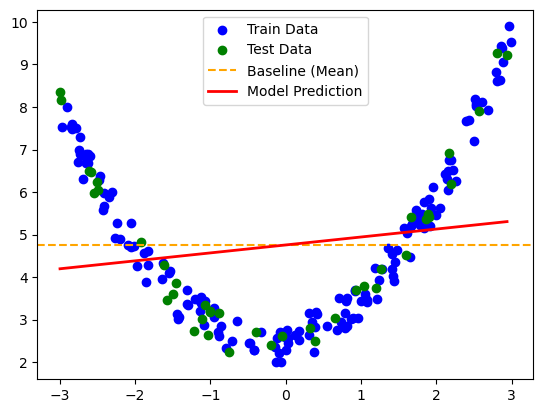

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Train data
plt.scatter(x_train, y_train, color='blue', label='Train Data')

# Test data
plt.scatter(x_test, y_test, color='green', label='Test Data')



y_mean = np.mean(y_train)
plt.axhline(y=y_mean, color='orange', linestyle='--', label='Baseline (Mean)')



# 1. Flatten x_test to 1D to get the sorting indices correctly
sorted_idx = x_test.flatten().argsort()

# 2. Use those indices and flatten the results for the plot function
x_sorted = x_test.flatten()[sorted_idx]
y_pred_sorted = y_pred.flatten()[sorted_idx]

# 3. Now plot (this will fix the dimension error)
plt.plot(x_sorted, y_pred_sorted, color='red', label='Model Prediction', linewidth=2)
plt.legend()
plt.show()

## Why the Linear Model Fails (Underfitting)

The visualization in Cell 14 demonstrates a classic case of **underfitting**. Here is a brief breakdown of why the current model is unsuccessful:

* **Model Complexity Mismatch:** The data follows a quadratic pattern, but the `LinearRegression` model is restricted to a straight line $y = mx + c$. It lacks the flexibility to follow the curve of the actual data.
* **High Bias:** Because the model makes strong, incorrect assumptions about the shape of the data, it ignores the actual trend, leading to high systematic error.
* **Poor Predictive Power:**
    * **$R^2$ Score $\approx 0.02$:** The model explains only 2% of the variance, making it nearly as ineffective as simply guessing the average value (the orange baseline).
    * **Residual Errors:** The distance between the predicted values $\hat{y}$ and the actual data points $y$ is very high, especially at the extremes of the $x$-axis.
* **The Necessity of Polynomials:** To capture this relationship, the input must be transformed using `PolynomialFeatures`. This allows the model to calculate $x^2$ terms, effectively turning the hypothesis into a quadratic equation: 

$$y = \beta_0 + \beta_1x + \beta_2x^2 + \epsilon$$ \epsilon$$

# Introduction to polynomial features

## Polynomial Features in Scikit-Learn

Polynomial features transform input data into a higher-dimensional space so that linear models can capture **non-linear relationships**.

A linear model normally learns:

$$
y = w_1 x + b
$$

But many real-world patterns are non-linear:

$$
y = w_1 x + w_2 x^2 + w_3 x^3 + b
$$

Polynomial features create these extra terms (**x², x³, etc.**) so a linear model can fit curved data.

---

### How It Works

`PolynomialFeatures` generates new features from existing ones.

**Example (1 feature):**
- Input: `[x]`
- Degree = 2 → `[x, x^2]`
- Degree = 3 → `[x, x^2, x^3]`

**Example (2 features):**
- Input: `[x1, x2]`
- Degree = 2 → `[x1, x2, x1^2, x1*x2, x2^2]`

---

### Code Example

```python
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)degree=2)
X_poly = poly.fit_transform(X)degree=2)
X_poly = poly.fit_transform(X)

## Creating Polynomial features for our inputs

In [63]:
poly = PolynomialFeatures(degree=2)
x_train_transf = poly.fit_transform(x_train)
print(x_train[0],'-------> [x]')
print(x_train_transf[0],'-------> [x^0, x^1, x^2] = [1, x , x^2]')

[1.6050584] -------> [x]
[1.         1.6050584  2.57621246] -------> [x^0, x^1, x^2] = [1, x , x^2]


In [36]:
# however if you want to exclude the intercept x^0

poly = PolynomialFeatures(degree=2, include_bias=False)
x_train_transf = poly.fit_transform(x_train)
print(x_train[0],'-------> [x]')
print(x_train_transf[0],'-------> [x^1, x^2] = [x , x^2]')

[1.6050584] -------> [x]
[1.6050584  2.57621246] -------> [x^1, x^2] = [x , x^2]


## Lets transform the x_test also.    Note: Run cell 63 before this

In [67]:
x_test_tranf = poly.transform(x_test)
x_test_tranf[0]

array([ 1.        , -1.00535167,  1.01073198])

## Fitting the Linear Regression model in the transformed data

In [71]:
lr = LinearRegression()
lr.fit(x_train_transf,y_train)
y_pred = lr.predict(x_test_tranf)

- Now, the features have become constants after transformation and coefficients are new variables whose degree is one hence we can fit a linear model onto them.

In [73]:
r2_score(y_test,y_pred)

0.9820615695137113

- You see the r_score has improved and is now closer to 1 suggesting a good fit.

## Coefficent and Intercept

In [75]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.28735263 0.70738999]]
[2.51846142]


## Visualising the model result

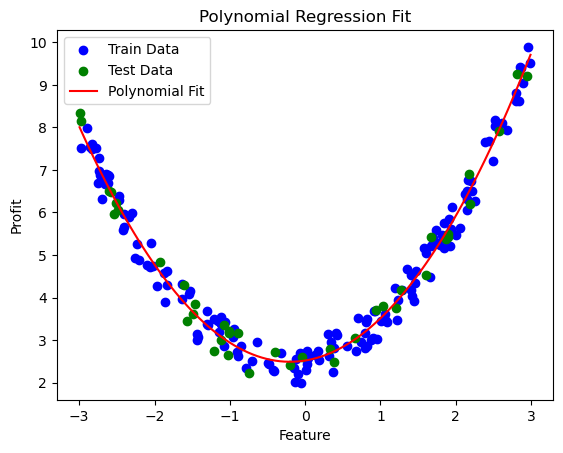

In [120]:
# Create a random linespace, it creates smooth continous linespace between two points.
x_range = np.linspace(x.min(), x.max(), 100).reshape(-1,1)   # -1 means figure the number of rows automatically and create evenly spaced 100 elements.

# Transform the space using the coeficients evaluated from original dataset.
x_range_poly = poly.fit_transform(x_range)

# Predict
y_range_pred = lr.predict(x_range_poly)


# Training data (green)
plt.scatter(x_train, y_train, color='blue', label='Train Data')

# Test data (blue)
plt.scatter(x_test, y_test, color='green', label='Test Data')

# Polynomial curve (red)
plt.plot(x_range, y_range_pred, color='red', label='Polynomial Fit')

plt.xlabel("Feature")
plt.ylabel("Profit")
plt.title("Polynomial Regression Fit")

plt.legend()
plt.show()

### Polynomial Regression Conclusion

The polynomial regression model provides a significantly better fit compared to a simple linear model by capturing the non-linear relationship between the feature and the target variable.

From the visualization, the red curve closely follows the pattern of the data points, indicating that the model successfully learns the underlying quadratic trend. Unlike linear regression, which would underfit this data, polynomial transformation enables the model to adapt to curvature in the data.

Additionally, both training (blue) and test (green) points align well with the fitted curve, suggesting that the model generalizes effectively and is not overfitting.

Overall, polynomial feature transformation improves model performance by allowing linear regression to model complex, non-linear relationships.